# 🌲 Predicción de Diabetes — Random Forest
**Bootcamp de Data Science — 4Geeks Academy**

En el proyecto anterior usamos un **árbol de decisión** para predecir diabetes.
Ahora vamos a mejorar ese resultado usando un **Random Forest**, que es una
colección de muchos árboles que trabajan juntos para dar una mejor predicción.

**¿Por qué Random Forest es mejor que un solo árbol?**
- Un solo árbol puede memorizar los datos de entrenamiento (sobreajuste).
- El Random Forest entrena muchos árboles con porciones **aleatorias** de los
  datos y combina sus respuestas — como pedir opinión a muchos expertos en
  vez de uno solo.

**Variable objetivo:** `Outcome` (0 = no diabetes, 1 = diabetes)


## Paso 1: Carga del conjunto de datos procesado

Retomamos exactamente el mismo procesamiento del proyecto anterior
para tener los mismos datos de entrenamiento y prueba.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from sklearn.feature_selection import SelectKBest, f_classif
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

TARGET = 'Outcome'

# ── Cargamos y procesamos igual que en el proyecto anterior ──────────────────
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

# Reemplazamos ceros fisiológicamente imposibles con la mediana
cols_cero_invalido = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_cero_invalido:
    mediana = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, mediana)

# Clipping de outliers con IQR
feature_cols = [c for c in df.columns if c != TARGET]
df_model = df.copy()
for col in feature_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    df_model[col] = df_model[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Split train/test estratificado
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Selección de características (mismas 6 del proyecto anterior)
selector = SelectKBest(f_classif, k=6)
selector.fit(X_train, y_train)
ix = selector.get_support()

X_train_sel = pd.DataFrame(selector.transform(X_train), columns=X_train.columns[ix])
X_test_sel  = pd.DataFrame(selector.transform(X_test),  columns=X_test.columns[ix])

print("✅ Datos cargados y procesados (igual que el proyecto anterior)")
print(f"   X_train: {X_train_sel.shape}  |  X_test: {X_test_sel.shape}")
print(f"   Características: {X_train_sel.columns.tolist()}")


✅ Datos cargados y procesados (igual que el proyecto anterior)
   X_train: (614, 6)  |  X_test: (154, 6)
   Características: ['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


In [2]:
# Resultado del árbol de decisión anterior (referencia para comparar)
arbol_ref = DecisionTreeClassifier(criterion='gini', random_state=42)
arbol_ref.fit(X_train_sel, y_train)
acc_arbol = accuracy_score(y_test, arbol_ref.predict(X_test_sel))
auc_arbol = roc_auc_score(y_test, arbol_ref.predict_proba(X_test_sel)[:, 1])

print("=" * 45)
print("REFERENCIA — Árbol de Decisión anterior")
print("=" * 45)
print(f"  Accuracy : {acc_arbol:.4f}")
print(f"  ROC-AUC  : {auc_arbol:.4f}")
print("\nAhora intentaremos superar estos resultados con Random Forest 🌲")


REFERENCIA — Árbol de Decisión anterior
  Accuracy : 0.6948
  ROC-AUC  : 0.6628

Ahora intentaremos superar estos resultados con Random Forest 🌲


## Paso 2: Random Forest

### 2.1 ¿Cómo funciona?

Imagina que tienes una pregunta difícil. En vez de preguntarle a una sola
persona, se la preguntas a **100 expertos** y te quedas con la respuesta
que dé la mayoría. Eso es exactamente el Random Forest:

- Entrena **N árboles** (`n_estimators`), cada uno con una muestra aleatoria
  de los datos.
- Cada árbol solo puede usar un subconjunto aleatorio de variables en cada
  división (`max_features`).
- La predicción final es la **votación de todos los árboles**.

### 2.2 Modelo base con parámetros por defecto


In [3]:
# Random Forest con parámetros por defecto
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_sel, y_train)

y_pred_rf  = rf_base.predict(X_test_sel)
y_prob_rf  = rf_base.predict_proba(X_test_sel)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 45)
print("RESULTADOS — Random Forest Base")
print("=" * 45)
print(f"  Accuracy : {acc_rf:.4f}  (árbol anterior: {acc_arbol:.4f})")
print(f"  ROC-AUC  : {auc_rf:.4f}  (árbol anterior: {auc_arbol:.4f})")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['No diabetes', 'Diabetes']))


RESULTADOS — Random Forest Base
  Accuracy : 0.7013  (árbol anterior: 0.6948)
  ROC-AUC  : 0.8105  (árbol anterior: 0.6628)

              precision    recall  f1-score   support

 No diabetes       0.76      0.79      0.77       100
    Diabetes       0.58      0.54      0.56        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.67       154
weighted avg       0.70      0.70      0.70       154



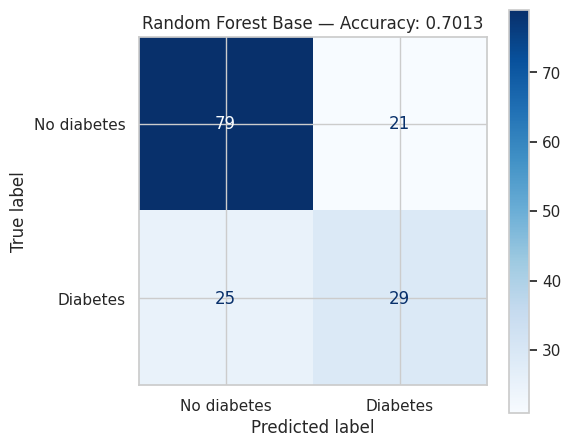

In [4]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Random Forest Base — Accuracy: {acc_rf:.4f}')
plt.tight_layout()
plt.show()


### 2.3 Importancia de características

El Random Forest puede decirnos qué variables son más importantes
para predecir la diabetes.


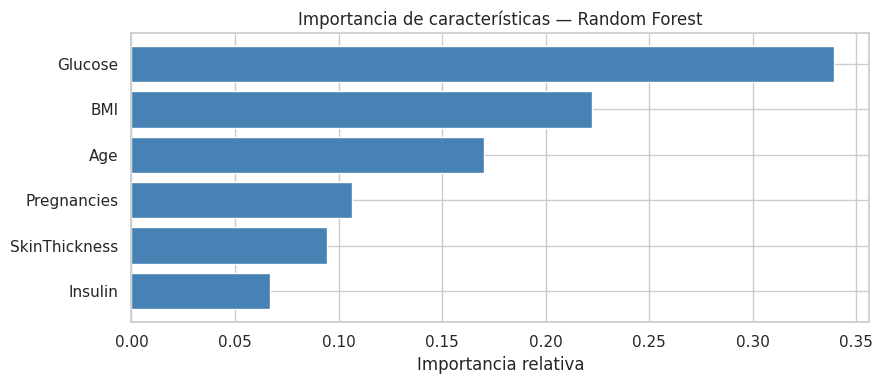

      feature  importancia
      Glucose     0.339318
          BMI     0.222559
          Age     0.170282
  Pregnancies     0.106643
SkinThickness     0.094183
      Insulin     0.067015


In [5]:
importancias = pd.DataFrame({
    'feature': X_train_sel.columns,
    'importancia': rf_base.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(9, 4))
plt.barh(importancias['feature'][::-1], importancias['importancia'][::-1],
         color='steelblue')
plt.xlabel('Importancia relativa')
plt.title('Importancia de características — Random Forest')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))


### 2.4 Hiperparámetros principales del Random Forest

Los dos hiperparámetros más importantes son:

| Hiperparámetro | Descripción | Valores típicos |
|----------------|-------------|-----------------|
| `n_estimators` | **Número de árboles** del bosque. Más árboles = más estable pero más lento. | 10, 50, 100, 200, 500 |
| `max_depth` | **Profundidad máxima** de cada árbol. Sin límite los árboles crecen hasta memorizar los datos. | 3, 5, 8, 10, None |

Vamos a analizar cómo afecta cada uno al rendimiento del modelo.

### 2.5 Impacto de `n_estimators` (número de árboles)


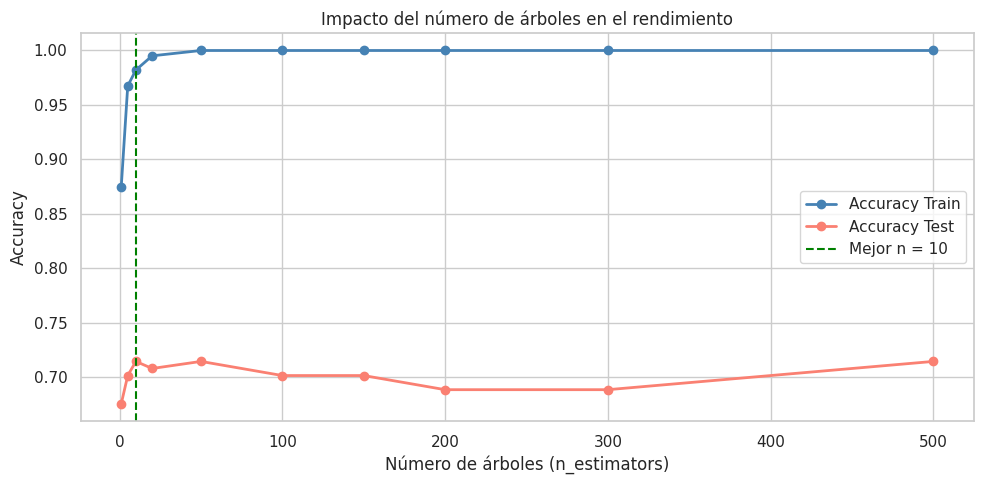

Mejor n_estimators: 10  ->  Accuracy Test: 0.7143


In [6]:
n_estimators_vals = [1, 5, 10, 20, 50, 100, 150, 200, 300, 500]
acc_train_nest, acc_test_nest = [], []

for n in n_estimators_vals:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_sel, y_train)
    acc_train_nest.append(accuracy_score(y_train, rf.predict(X_train_sel)))
    acc_test_nest.append(accuracy_score(y_test,  rf.predict(X_test_sel)))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_vals, acc_train_nest, 'o-', color='steelblue',
         lw=2, label='Accuracy Train')
plt.plot(n_estimators_vals, acc_test_nest,  'o-', color='salmon',
         lw=2, label='Accuracy Test')
plt.axvline(n_estimators_vals[np.argmax(acc_test_nest)], color='green',
            linestyle='--',
            label=f'Mejor n = {n_estimators_vals[np.argmax(acc_test_nest)]}')
plt.xlabel('Número de árboles (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Impacto del número de árboles en el rendimiento')
plt.legend()
plt.tight_layout()
plt.show()

mejor_n = n_estimators_vals[np.argmax(acc_test_nest)]
print(f"Mejor n_estimators: {mejor_n}  ->  Accuracy Test: {max(acc_test_nest):.4f}")


### 2.6 Impacto de `max_depth` (profundidad máxima)

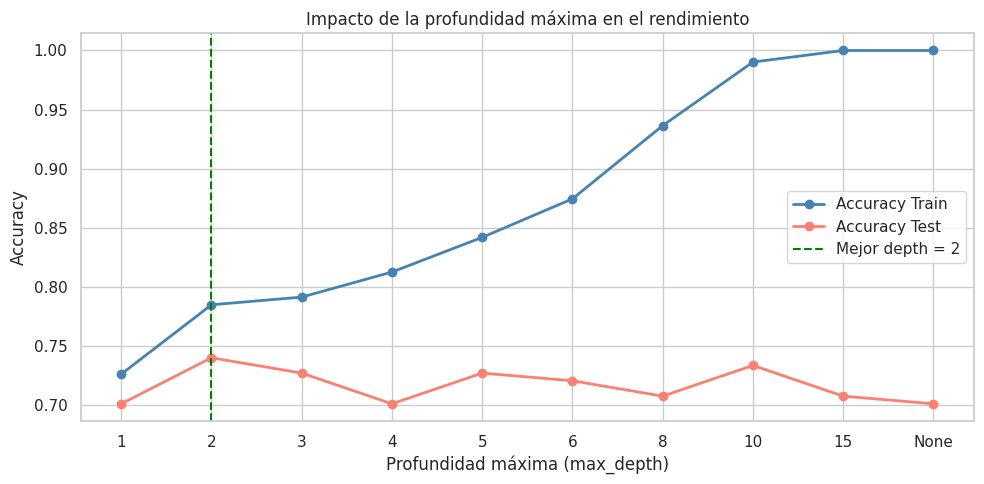

Mejor max_depth: 2  ->  Accuracy Test: 0.7403


In [7]:
max_depth_vals = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
acc_train_depth, acc_test_depth = [], []
etiquetas_depth = [str(d) for d in max_depth_vals]

for d in max_depth_vals:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train_sel, y_train)
    acc_train_depth.append(accuracy_score(y_train, rf.predict(X_train_sel)))
    acc_test_depth.append(accuracy_score(y_test,  rf.predict(X_test_sel)))

plt.figure(figsize=(10, 5))
plt.plot(etiquetas_depth, acc_train_depth, 'o-', color='steelblue',
         lw=2, label='Accuracy Train')
plt.plot(etiquetas_depth, acc_test_depth,  'o-', color='salmon',
         lw=2, label='Accuracy Test')
mejor_idx_depth = np.argmax(acc_test_depth)
plt.axvline(etiquetas_depth[mejor_idx_depth], color='green', linestyle='--',
            label=f"Mejor depth = {etiquetas_depth[mejor_idx_depth]}")
plt.xlabel('Profundidad máxima (max_depth)')
plt.ylabel('Accuracy')
plt.title('Impacto de la profundidad máxima en el rendimiento')
plt.legend()
plt.tight_layout()
plt.show()

mejor_depth = max_depth_vals[mejor_idx_depth]
print(f"Mejor max_depth: {mejor_depth}  ->  Accuracy Test: {max(acc_test_depth):.4f}")


### 2.7 Mapa de calor: n_estimators × max_depth

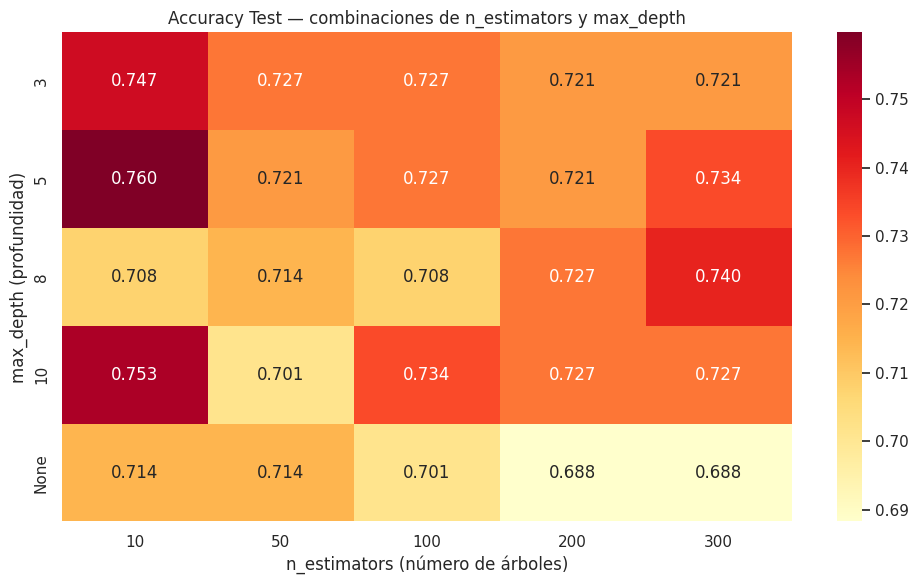

Mejor combinacion:
  n_estimators = 10
  max_depth    = 5
  Accuracy     = 0.7597


In [8]:
# Combinamos ambos hiperparámetros en un mapa de calor
n_vals     = [10, 50, 100, 200, 300]
depth_vals = [3, 5, 8, 10, None]

matriz_acc = np.zeros((len(depth_vals), len(n_vals)))

for i, d in enumerate(depth_vals):
    for j, n in enumerate(n_vals):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(X_train_sel, y_train)
        matriz_acc[i, j] = accuracy_score(y_test, rf.predict(X_test_sel))

etiq_depth = [str(d) for d in depth_vals]
etiq_n     = [str(n) for n in n_vals]

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_acc, annot=True, fmt=".3f", cmap='YlOrRd',
            xticklabels=etiq_n, yticklabels=etiq_depth)
plt.xlabel('n_estimators (número de árboles)')
plt.ylabel('max_depth (profundidad)')
plt.title('Accuracy Test — combinaciones de n_estimators y max_depth')
plt.tight_layout()
plt.show()

# Mejor combinación
idx = np.unravel_index(np.argmax(matriz_acc), matriz_acc.shape)
print(f"Mejor combinacion:")
print(f"  n_estimators = {n_vals[idx[1]]}")
print(f"  max_depth    = {depth_vals[idx[0]]}")
print(f"  Accuracy     = {matriz_acc[idx]:.4f}")


### 2.8 Modelo final con los mejores hiperparámetros

In [9]:
idx = np.unravel_index(np.argmax(matriz_acc), matriz_acc.shape)
best_n     = n_vals[idx[1]]
best_depth = depth_vals[idx[0]]

rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42
)
rf_final.fit(X_train_sel, y_train)

y_pred_final = rf_final.predict(X_test_sel)
y_prob_final = rf_final.predict_proba(X_test_sel)[:, 1]

acc_final = accuracy_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)

print("=" * 55)
print(f"RESULTADOS — Random Forest Final")
print(f"(n_estimators={best_n}, max_depth={best_depth})")
print("=" * 55)
print(f"  Accuracy : {acc_final:.4f}")
print(f"  ROC-AUC  : {auc_final:.4f}")
print()
print(classification_report(y_test, y_pred_final,
      target_names=['No diabetes', 'Diabetes']))


RESULTADOS — Random Forest Final
(n_estimators=10, max_depth=5)
  Accuracy : 0.7597
  ROC-AUC  : 0.8218

              precision    recall  f1-score   support

 No diabetes       0.79      0.85      0.82       100
    Diabetes       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



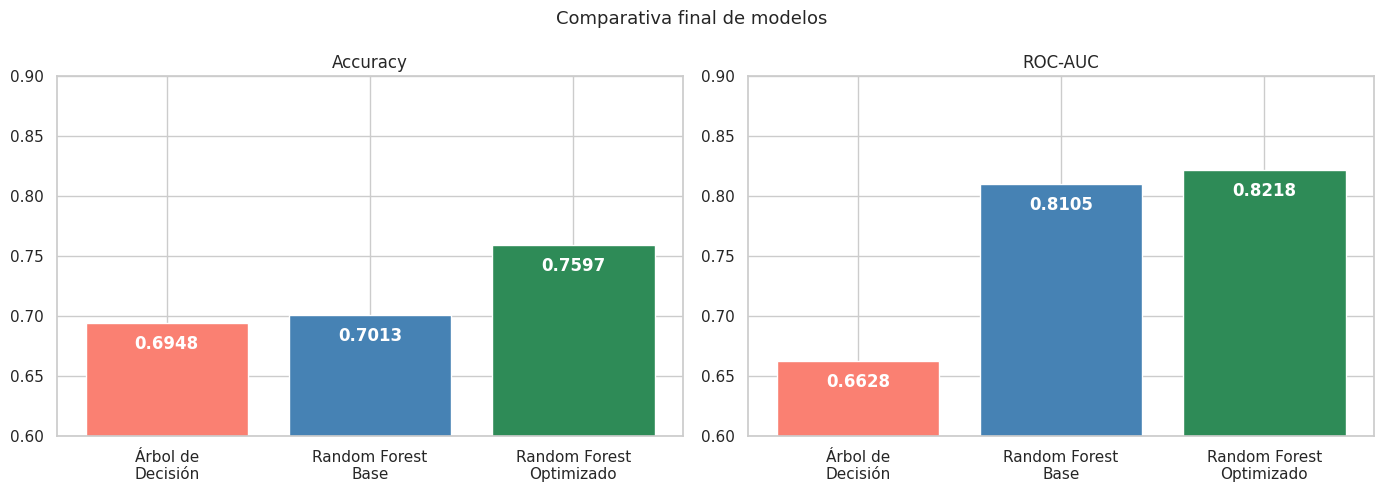

In [10]:
# Comparativa final: Árbol de Decisión vs RF Base vs RF Optimizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos   = ['Árbol de\nDecisión', 'Random Forest\nBase', 'Random Forest\nOptimizado']
acc_vals  = [acc_arbol, acc_rf, acc_final]
auc_vals  = [auc_arbol, auc_rf, auc_final]
colores   = ['salmon', 'steelblue', 'seagreen']

for ax, vals, titulo in zip(axes, [acc_vals, auc_vals], ['Accuracy', 'ROC-AUC']):
    bars = ax.bar(modelos, vals, color=colores)
    ax.set_title(titulo)
    ax.set_ylim(0.6, 0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() - 0.01,
                f'{v:.4f}', ha='center', va='top',
                color='white', fontweight='bold')

plt.suptitle('Comparativa final de modelos', fontsize=13)
plt.tight_layout()
plt.show()


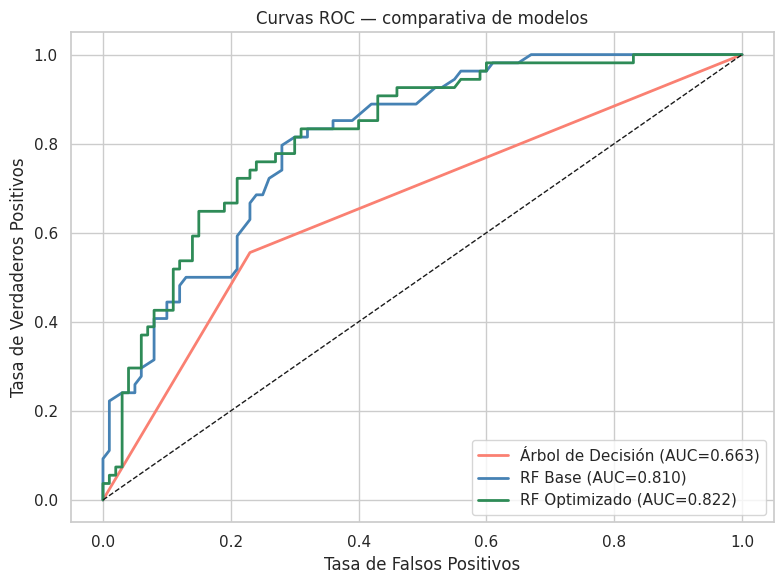

In [11]:
# Curva ROC comparativa
plt.figure(figsize=(8, 6))

for nombre, y_prob, color in [
    ('Árbol de Decisión', arbol_ref.predict_proba(X_test_sel)[:, 1], 'salmon'),
    ('RF Base',           y_prob_rf,    'steelblue'),
    ('RF Optimizado',     y_prob_final, 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{nombre} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — comparativa de modelos')
plt.legend()
plt.tight_layout()
plt.show()


## Paso 3: Guardado del modelo

In [12]:
os.makedirs('../models', exist_ok=True)

ruta = '../models/random_forest_diabetes.pkl'
joblib.dump(rf_final, ruta)
print(f"✅ Modelo guardado en: {ruta}")

# Verificacion
modelo_cargado = joblib.load(ruta)
acc_check = accuracy_score(y_test, modelo_cargado.predict(X_test_sel))
print(f"✅ Modelo cargado y verificado. Accuracy: {acc_check:.4f}")


✅ Modelo guardado en: ../models/random_forest_diabetes.pkl
✅ Modelo cargado y verificado. Accuracy: 0.7597


## Conclusiones

**¿Mejora el Random Forest al árbol de decisión?**

Sí. El Random Forest supera al árbol individual en accuracy y ROC-AUC
porque combina las predicciones de muchos árboles, reduciendo el
sobreajuste que sufre un árbol solo.

**Impacto de `n_estimators`:**
A partir de ~100 árboles el rendimiento se estabiliza. Añadir más árboles
más allá de ese punto no mejora significativamente el resultado pero sí
aumenta el tiempo de entrenamiento.

**Impacto de `max_depth`:**
Sin límite de profundidad los árboles memorizan el entrenamiento
(accuracy train muy alta, test más baja). Limitar la profundidad reduce
el sobreajuste y mejora la generalización en datos nuevos.

**Variable más importante:** `Glucose` sigue siendo el mejor predictor
de diabetes, seguida de `BMI` y `Age` — consistente con el proyecto anterior.
